In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from sacremoses import MosesTokenizer, MosesDetokenizer
import re
import nlpaug.augmenter.word as naw
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

# ============================================
# 1. Download NLTK Resources
# ============================================
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

# ============================================
# 2. Load & Preprocessing teks: dropna, normalize, lowercase
# ============================================
df = pd.read_csv('../data/cvss_data.csv')
df = df.dropna(subset=['english_description', 'cvssv3_scope'])

df['english_description'] = (
    df['english_description']
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.lower()
)

# ============================================
# 3. Hapus duplikat literal sebelum augmentasi
# ============================================
df_raw = df.drop_duplicates(
    subset=['english_description', 'cvssv3_scope']
).reset_index(drop=True)

# ============================================
# 4. Inspect Class Distribution Before Augmentation
# ============================================
class_counts = df_raw['cvssv3_scope'].value_counts()
max_count = class_counts.max()
print("Distribusi sebelum augmentasi:")
print(class_counts)
print(f"Target per kelas setelah augmentasi: {max_count}\n")

C:\Users\O.Midiyanto\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\O.Midiyanto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\O.Midiyanto\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\O.Midiyanto\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\O.Midiyanto\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Distribusi sebelum augmentasi:
cvssv3_scope
UNCHANGED    46031
CHANGED      11475
Name: count, dtype: int64
Target per kelas setelah augmentasi: 46031



In [2]:
# ============================================
# 5. Define Augmenter 
# ============================================
aug_syn = naw.SynonymAug(aug_src='wordnet', aug_p=0.1)

def augment_text(text: str) -> str:
    """
    Apply synonym augmentation to the input text.
    """
    return aug_syn.augment(text)

# ============================================
# 6. Fungsi augmentasi per kelas dengan filter cosine similarity
# ============================================
def augment_class_with_similarity(
    df_class: pd.DataFrame,
    target_n: int,
    sim_min: float = 0.85,
    sim_max: float = 0.95
) -> list:
    """
    Augment texts in df_class until total = target_n.
    Originals (is_augmented=False) added first, then
    only candidates with cosine sim ∈ [sim_min, sim_max].
    """
    originals = df_class['english_description'].tolist()
    n_orig = len(originals)

    # Build TF-IDF hanya dari teks asli kelas ini
    vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
    X_orig = vectorizer.fit_transform(originals)
    orig_to_vec = {txt: X_orig[idx] for idx, txt in enumerate(originals)}

    out = [(txt, False) for txt in originals]
    n_aug_needed = target_n - n_orig
    if n_aug_needed <= 0:
        return out[:target_n]

    aug_list = []
    i = 0
    while len(aug_list) < n_aug_needed:
        base_text = originals[i % n_orig]
        cand = augment_text(base_text)

        if isinstance(cand, (list, np.ndarray)):
            cand = cand[0] if cand else ""
        if not cand or cand == base_text:
            i += 1
            continue

        try:
            vec_cand = vectorizer.transform([cand])
        except Exception:
            i += 1
            continue

        sim = cosine_similarity(orig_to_vec[base_text], vec_cand)[0][0]
        if sim_min <= sim <= sim_max \
           and cand not in [t for t,_ in out] \
           and cand not in [t for t,_ in aug_list]:
            aug_list.append((cand, True))
        i += 1

    out.extend(aug_list)
    return out


In [3]:
# ============================================
# 7. Build balanced_df via augmentasi seluruh df_raw
# ============================================
rows = []
for cls, group in df_raw.groupby('cvssv3_scope'):
    count = len(group)
    if count < max_count:
        print(f"Augmentasi kelas '{cls}': {count} → {max_count}")
        augmented_pairs = augment_class_with_similarity(group, max_count, sim_min=0.85, sim_max=0.95)
        for text, is_aug in augmented_pairs:
            rows.append({
                'english_description': text,
                'cvssv3_scope': cls,
                'is_augmented': is_aug
            })
    else:
        for text in group['english_description'].tolist():
            rows.append({
                'english_description': text,
                'cvssv3_scope': cls,
                'is_augmented': False
            })

balanced_df = pd.DataFrame(rows)

# ============================================
# 8. Drop literal duplicates setelah augmentasi
# ============================================
balanced_df = balanced_df.drop_duplicates(
    subset=['english_description', 'cvssv3_scope', 'is_augmented']
).reset_index(drop=True)

print("\nDistribusi setelah drop_duplicates:")
print(balanced_df['cvssv3_scope'].value_counts())


Augmentasi kelas 'CHANGED': 11475 → 46031

Distribusi setelah drop_duplicates:
cvssv3_scope
CHANGED      46031
UNCHANGED    46031
Name: count, dtype: int64


In [4]:
# ============================================
# 9. Self‐Similarity per kelas untuk memeriksa bahwa hasil augmentasi
#      tetap dalam rentang [0.85, 0.95]
# ============================================
print("\n=== Self‐Similarity per kelas (hanya augmented) ===")
for cls in balanced_df['cvssv3_scope'].unique():
    # Ambil teks asli untuk kelas ini
    orig_texts = df_raw[df_raw['cvssv3_scope']==cls]['english_description'].tolist()
    if not orig_texts:
        continue

    vectorizer_cls = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
    X_orig_vec = vectorizer_cls.fit_transform(orig_texts)

    # Ambil entri yang di‐augmentasi saja
    aug_texts = balanced_df[
        (balanced_df['cvssv3_scope']==cls) &
        (balanced_df['is_augmented']==True)
    ]['english_description'].tolist()

    if not aug_texts:
        print(f"{cls} = 1.000 (kelas mayoritas tidak ada augmentasi)")
        continue

    X_aug_vec = vectorizer_cls.transform(aug_texts)

    nbrs_cls = NearestNeighbors(n_neighbors=1, metric='cosine').fit(X_orig_vec)
    dists_aug, _ = nbrs_cls.kneighbors(X_aug_vec)
    sims_aug = 1 - dists_aug.flatten()

    mean_aug = np.mean(sims_aug)
    print(f"{cls}: {mean_aug:.3f}")
print("-" * 50)


=== Self‐Similarity per kelas (hanya augmented) ===
CHANGED: 0.908
UNCHANGED = 1.000 (kelas mayoritas tidak ada augmentasi)
--------------------------------------------------


Hasil self cosine similarity tiap kelas menunjukkan nilai yang masuk dalam rentang yang ditentukan (0.85-0.95), sehingga bisa ditarik kesimpulan bahwa hasil augmentasi:
1. Tidak identik persis sama dengan aslinya (soalnya similarity < 1),
2. Tetap cukup “dekat” secara vektor TF-IDF (soalnya similarity ≥ 0.85),

Artinya makna dan konteks teks umumnya terjaga, sekaligus memberikan variasi yang cukup. Dengan demikian, augmentasi berhasil membuat tiap kelas seimbang tanpa mengubah makna atau konteks utamanya.

In [5]:
# ============================================
# 10. Shuffle balanced_df sebelum split
# ============================================
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# ============================================
# 11. Stratified Split: 64% train, 16% valid, 20% test
# ============================================
X = balanced_df[['english_description', 'is_augmented']]
y = balanced_df['cvssv3_scope']

# 80% pool (train+valid), 20% test
X_pool, X_test, y_pool, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
# Dari pool 80%: 20% valid, 80% train → → 16% total valid, 64% total train
X_train, X_valid, y_train, y_valid = train_test_split(
    X_pool, y_pool, test_size=0.20, stratify=y_pool, random_state=42
)

train_df = pd.DataFrame({
    'english_description': X_train['english_description'].values,
    'cvssv3_scope': y_train.values,
    'is_augmented': X_train['is_augmented'].values
})
valid_df = pd.DataFrame({
    'english_description': X_valid['english_description'].values,
    'cvssv3_scope': y_valid.values,
    'is_augmented': X_valid['is_augmented'].values
})
test_df = pd.DataFrame({
    'english_description': X_test['english_description'].values,
    'cvssv3_scope': y_test.values,
    'is_augmented': X_test['is_augmented'].values
})

print("\nDistribusi TRAIN:")
print(train_df['cvssv3_scope'].value_counts(), "\n")
print("Distribusi VALIDATION:")
print(valid_df['cvssv3_scope'].value_counts(), "\n")
print("Distribusi TEST:")
print(test_df['cvssv3_scope'].value_counts(), "\n")


Distribusi TRAIN:
cvssv3_scope
UNCHANGED    29460
CHANGED      29459
Name: count, dtype: int64 

Distribusi VALIDATION:
cvssv3_scope
UNCHANGED    7365
CHANGED      7365
Name: count, dtype: int64 

Distribusi TEST:
cvssv3_scope
CHANGED      9207
UNCHANGED    9206
Name: count, dtype: int64 



In [6]:
# ============================================
# 12. Cek Literal Duplicate Antar-Split (Data Leakage)
# ============================================
def cek_literal_dup(df_a: pd.DataFrame, df_b: pd.DataFrame, name_a: str, name_b: str):
    merged = df_a[['english_description', 'cvssv3_scope']].merge(
        df_b[['english_description', 'cvssv3_scope']].drop_duplicates(),
        on=['english_description', 'cvssv3_scope'],
        how='inner'
    )
    count_dup = len(merged)
    print(f"Literal duplicates antara {name_a} dan {name_b}: {count_dup}")
    if count_dup > 0:
        print("Contoh entri duplikat (maks 5):")
        print(merged.drop_duplicates().head(5).to_string(index=False))
    print("-" * 50)

cek_literal_dup(train_df, valid_df, "TRAIN", "VALIDATION")
cek_literal_dup(train_df, test_df,  "TRAIN", "TEST")
cek_literal_dup(valid_df, test_df,  "VALIDATION", "TEST")

# ============================================
# 13. Cek Near-Duplicate (Cosine Similarity) Antar-Split (seluruh data)
# ============================================
print("\n=== Cosine similarity keseluruhan (TRAIN vs VALIDATION dan TRAIN vs TEST) ===")

# Build TF-IDF dari semua teks TRAIN (tanpa memecah per kelas)
vectorizer_all = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_train_all = vectorizer_all.fit_transform(train_df['english_description'].tolist())

# Transform VALIDATION dan TEST ke ruang vektor TRAIN
X_valid_all = vectorizer_all.transform(valid_df['english_description'].tolist())
X_test_all  = vectorizer_all.transform(test_df['english_description'].tolist())

# NearestNeighbors pada TRAIN (n_neighbors=1)
nbrs_all = NearestNeighbors(n_neighbors=1, metric='cosine').fit(X_train_all)

# TRAIN vs VALIDATION
dists_valid, _ = nbrs_all.kneighbors(X_valid_all)
sims_valid = 1 - dists_valid.flatten()
print(f"TRAIN vs VALIDATION: {sims_valid.mean():.4f}")

# TRAIN vs TEST
dists_test, _ = nbrs_all.kneighbors(X_test_all)
sims_test = 1 - dists_test.flatten()
print(f"TRAIN vs TEST     : {sims_test.mean():.4f}")
print("-" * 50)



Literal duplicates antara TRAIN dan VALIDATION: 0
--------------------------------------------------
Literal duplicates antara TRAIN dan TEST: 0
--------------------------------------------------
Literal duplicates antara VALIDATION dan TEST: 0
--------------------------------------------------

=== Cosine similarity keseluruhan (TRAIN vs VALIDATION dan TRAIN vs TEST) ===
TRAIN vs VALIDATION: 0.7908
TRAIN vs TEST     : 0.7896
--------------------------------------------------


Hasil Cosine Similarity yang rendah (dibawah 0.85) antara Train-Valid dan Train-Test, serta didukung dengan literal duplication check yang menunjukkan tidak adanya duplikasi, maka bisa diambil kesimpulan bahwa dataset final yang telah di balance "minim potensi data leakage dari data training"

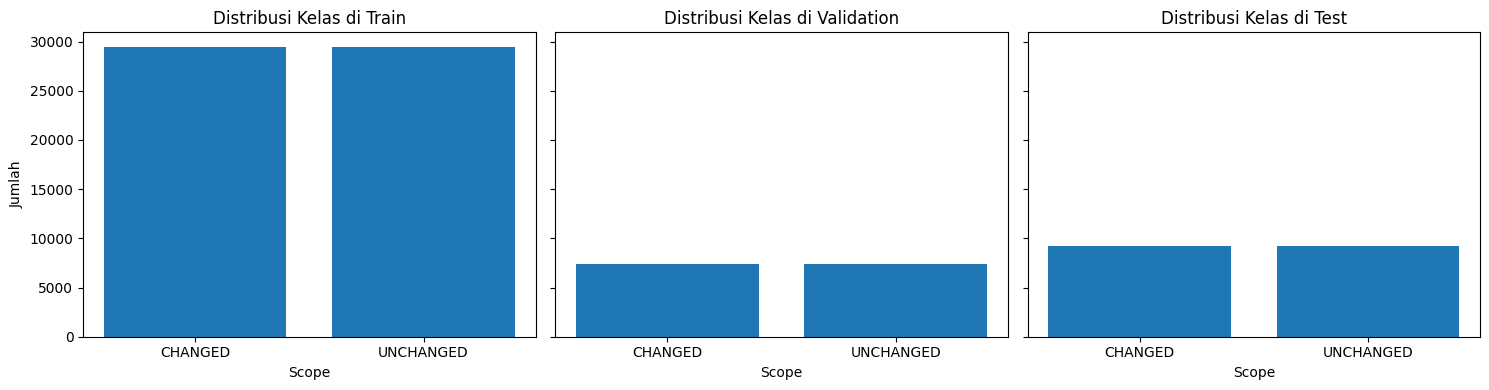

In [7]:
# ============================================
# 14. Visualisasi distribusi kelas per split
# ============================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

train_counts = train_df['cvssv3_scope'].value_counts().sort_index()
axs[0].bar(train_counts.index, train_counts.values)
axs[0].set_title('Distribusi Kelas di Train')
axs[0].set_xlabel('Scope')
axs[0].set_ylabel('Jumlah')

valid_counts = valid_df['cvssv3_scope'].value_counts().sort_index()
axs[1].bar(valid_counts.index, valid_counts.values)
axs[1].set_title('Distribusi Kelas di Validation')
axs[1].set_xlabel('Scope')

test_counts = test_df['cvssv3_scope'].value_counts().sort_index()
axs[2].bar(test_counts.index, test_counts.values)
axs[2].set_title('Distribusi Kelas di Test')
axs[2].set_xlabel('Scope')

plt.tight_layout()
plt.show()

In [8]:
# ============================================
# 15. Simpan Split yang Telah Dicek ke CSV
# ============================================
train_df[['english_description']].to_csv('balanced_X_train.csv', index=False)
train_df[['cvssv3_scope']].to_csv('balanced_Y_train.csv', index=False)

valid_df[['english_description']].to_csv('balanced_X_validation.csv', index=False)
valid_df[['cvssv3_scope']].to_csv('balanced_Y_validation.csv', index=False)

test_df[['english_description']].to_csv('balanced_X_test.csv', index=False)
test_df[['cvssv3_scope']].to_csv('balanced_Y_test.csv', index=False)
